# UPI Payment Trends Analysis
## Step 1 — Import Libraries

In [1]:
# Import all libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2 — Load Dataset

In [2]:
# Load the dataset
df=pd.read_csv('upi_data.csv')

In [3]:
df

,Month,Financial_Year,No_of_Banks,Volume_Mn,Value_Cr
0,March-2017,2016-17,44,6.37,2425.14
1,February-2017,2016-17,44,4.38,1937.71
2,January-2017,2016-17,36,4.46,1696.22
3,December-2016,2016-17,35,1.99,707.93
4,November-2016,2016-17,30,0.29,100.46
...,...,...,...,...,...
115,August-2025,2025-26,688,20008.31,2485472.91
116,July-2025,2025-26,684,19467.95,2508498.09
117,June-2025,2025-26,675,18395.01,2403930.69
118,May-2025,2025-26,673,18677.46,2514297.01


In [4]:
# Preview first 5 rows
print("First 5 rows:")
print(df.head())

First 5 rows:
           Month Financial_Year  No_of_Banks  Volume_Mn  Value_Cr
0     March-2017        2016-17           44       6.37   2425.14
1  February-2017        2016-17           44       4.38   1937.71
2   January-2017        2016-17           36       4.46   1696.22
3  December-2016        2016-17           35       1.99    707.93
4  November-2016        2016-17           30       0.29    100.46


## Step 3 — Explore Dataset

In [5]:
print("First 5 rows:")
print(df.head())

First 5 rows:
           Month Financial_Year  No_of_Banks  Volume_Mn  Value_Cr
0     March-2017        2016-17           44       6.37   2425.14
1  February-2017        2016-17           44       4.38   1937.71
2   January-2017        2016-17           36       4.46   1696.22
3  December-2016        2016-17           35       1.99    707.93
4  November-2016        2016-17           30       0.29    100.46


In [6]:
print("Last 5 rows:")
print(df.tail())

Last 5 rows:
           Month Financial_Year  No_of_Banks  Volume_Mn    Value_Cr
115  August-2025        2025-26          688   20008.31  2485472.91
116    July-2025        2025-26          684   19467.95  2508498.09
117    June-2025        2025-26          675   18395.01  2403930.69
118     May-2025        2025-26          673   18677.46  2514297.01
119   April-2025        2025-26          668   17893.42  2394925.87


In [7]:
# Shape
print("Shape:", df.shape)

Shape: (120, 5)


* 120 rows
* 5 columns

In [8]:
#size
df.size 

600

In [9]:
#Dimensions
df.ndim

2

In [10]:
#columns
print("\nColumns:",df.columns.tolist())


Columns: ['Month', 'Financial_Year', 'No_of_Banks', 'Volume_Mn', 'Value_Cr']


In [11]:
# Full overview
print("Dataset info:")
df.info()

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Month           120 non-null    object 
 1   Financial_Year  120 non-null    object 
 2   No_of_Banks     120 non-null    int64  
 3   Volume_Mn       120 non-null    float64
 4   Value_Cr        120 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 4.8+ KB


In [12]:
# Statistics of numeric columns
print("Basic Statistics:")
df.describe()

Basic Statistics:


,No_of_Banks,Volume_Mn,Value_Cr
count,120.000000,120.000000,1.200000e+02
mean,296.875000,6079.210500,8.920223e+05
std,225.203085,6890.973131,9.266852e+05
min,21.000000,0.000000,0.000000e+00
25%,126.500000,463.237500,7.119254e+04
50%,218.000000,2590.315000,4.921512e+05
75%,495.250000,10748.337500,1.613292e+06
max,705.000000,22641.110000,2.952542e+06


In [13]:
# Random 5 rows
print("Random Sample of 5 rows:")
df.sample(5)

Random Sample of 5 rows:


,Month,Financial_Year,No_of_Banks,Volume_Mn,Value_Cr
77,October-2022,2022-23,365,7305.42,1211582.51
82,May-2022,2022-23,323,5955.20,1041520.07
21,June-2017,2017-18,52,10.35,3098.36
105,June-2024,2024-25,602,13885.14,2007081.20
109,February-2026,2025-26,694,20394.18,2684229.29


In [14]:
#Check Missing Values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Month             0
Financial_Year    0
No_of_Banks       0
Volume_Mn         0
Value_Cr          0
dtype: int64


In [15]:
# Check duplicates
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


In [16]:
# Unique values per column
print("Unique Values per Column:")
print(df.nunique())

Unique Values per Column:
Month             120
Financial_Year     10
No_of_Banks       103
Volume_Mn         116
Value_Cr          118
dtype: int64


In [17]:
# Year wise count
print("Year-wise data Count:")
print(df.Financial_Year.value_counts())

Year-wise data Count:
Financial_Year
2016-17    12
2017-18    12
2018-19    12
2019-20    12
2020-21    12
2021-22    12
2022-23    12
2023-24    12
2024-25    12
2025-26    12
Name: count, dtype: int64


- ✅ Month = 12 — 12 unique months perfect!
- ✅ Financial_Year = 10 — 10 years of data!
- ✅ Each year = 12 — balanced data, every year has 12 months!

In [18]:
# Correlation between numeric columns
print("Correlation:")
df.corr(numeric_only=True)

Correlation:


,No_of_Banks,Volume_Mn,Value_Cr
No_of_Banks,1.000000,0.980367,0.991636
Volume_Mn,0.980367,1.000000,0.994064
Value_Cr,0.991636,0.994064,1.000000


- ✅ Values close to 1.0 = Strong positive correlation
- ✅ Volume & Value = 0.99 — means when transactions increase, value also increases!
- ✅ No_of_Banks & Volume = 0.98 — more banks = more transactions!

## Step 4 — Data Cleaning

### 4.1 — Confirm No Duplicates

In [19]:
# Confirm no duplicates
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


#### If Duplicates are found - Handle Them

In [20]:
# If no duplicates
if df.duplicated().sum() == 0:
    print("No duplicates found! Data is clean!")

# If duplicates found
else:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed!")
    print("New shape:", df.shape)

No duplicates found! Data is clean!


### 4.2 — Confirm No Missing Values

In [21]:
# Confirm no missing values
print('Missing Values:')
print(df.isnull().sum())
print("\nTotal Missing values:", df.isnull().sum().sum())

Missing Values:
Month             0
Financial_Year    0
No_of_Banks       0
Volume_Mn         0
Value_Cr          0
dtype: int64

Total Missing values: 0


#### If missing values Found - Handle Them

In [22]:
# If no missing values
if df.isnull().sum().sum() == 0:
    print("\nNo missing values found! Data is clean!")

# If missing values found
else:
    # No_of_Banks - no outliers - use mean
    df['No_of_Banks'].fillna(df['No_of_Banks'].mean(), inplace=True)
    
    # Volume_Mn - has outliers - use median
    df['Volume_Mn'].fillna(df['Volume_Mn'].median(), inplace=True)
    
    # Value_Cr - has outliers - use median
    df['Value_Cr'].fillna(df['Value_Cr'].median(), inplace=True)
    
    print("Missing values handled!")


No missing values found! Data is clean!


### 4.3 — Datatype Validation & Conversion

In [23]:
# Check current datatypes
Before_Conversion = df.dtypes.reset_index()
Before_Conversion.columns = ['Column', 'Before_Conversion']

In [24]:
# Convert Month to DateTime
df['Month'] = pd.to_datetime(df['Month'], format='%B-%Y')

In [25]:
#Check Datatypes After Conversion
After_Conversion = df.dtypes.reset_index()
After_Conversion.columns = ['Column', 'After_Conversion']

In [26]:
#Merge Both in to one Table
Comparision = Before_Conversion.merge(After_Conversion, on='Column')

In [27]:
print("DataType Comparision Table:\n")
Comparision

DataType Comparision Table:



,Column,Before_Conversion,After_Conversion
0,Month,object,datetime64[ns]
1,Financial_Year,object,object
2,No_of_Banks,int64,int64
3,Volume_Mn,float64,float64
4,Value_Cr,float64,float64


### 4.4 — Standardization & Normalization

- If column has LIMITED categories  → check unique values
- If column has ALL different values → skip unique check

In [28]:
# Check Financial_Year column consistency
print("Financial Year unique values:\n")
print(df['Financial_Year'].unique())

Financial Year unique values:

['2016-17' '2017-18' '2018-19' '2019-20' '2020-21' '2021-22' '2022-23'
 '2023-24' '2024-25' '2025-26']


In [29]:
# Check total unique year
print("\nTotal unique years:", df['Financial_Year'].nunique())


Total unique years: 10


In [30]:
#If any extra spaces in text columns u can remove spaces 
df['Financial_Year'] = df['Financial_Year'].str.strip()
print("Financial_Year cleaned!")

Financial_Year cleaned!


In [31]:
print("\nAfter Standardization:\n")
print(df.head())


After Standardization:

       Month Financial_Year  No_of_Banks  Volume_Mn  Value_Cr
0 2017-03-01        2016-17           44       6.37   2425.14
1 2017-02-01        2016-17           44       4.38   1937.71
2 2017-01-01        2016-17           36       4.46   1696.22
3 2016-12-01        2016-17           35       1.99    707.93
4 2016-11-01        2016-17           30       0.29    100.46


### 4.5 — Column Renaming & Formatting

* Column Renaming & Formatting :- Code looks clean & professional

In [32]:
# Check current column names
print("Before Renaming:\n")
print(df.columns.tolist())

Before Renaming:

['Month', 'Financial_Year', 'No_of_Banks', 'Volume_Mn', 'Value_Cr']


In [33]:
# Rename columns to cleaner names
df.rename(columns={'Month':'Month','Financial_Year':'Financial_Year','No_of_Banks':'Bank_Count','Volume_Mn':'Transaction_Volume_Mn','Value_Cr':'Transaction_Value_Cr'},inplace=True)

In [34]:
#Check After Renamings
print("After Renaming:\n")
print(df.columns.tolist())

After Renaming:

['Month', 'Financial_Year', 'Bank_Count', 'Transaction_Volume_Mn', 'Transaction_Value_Cr']


### 4.6 — Outlier Detection
#### 4.6.1 — Distribution using Histplot

#### 4.6.2 — Outliers Detection by using Boxplot

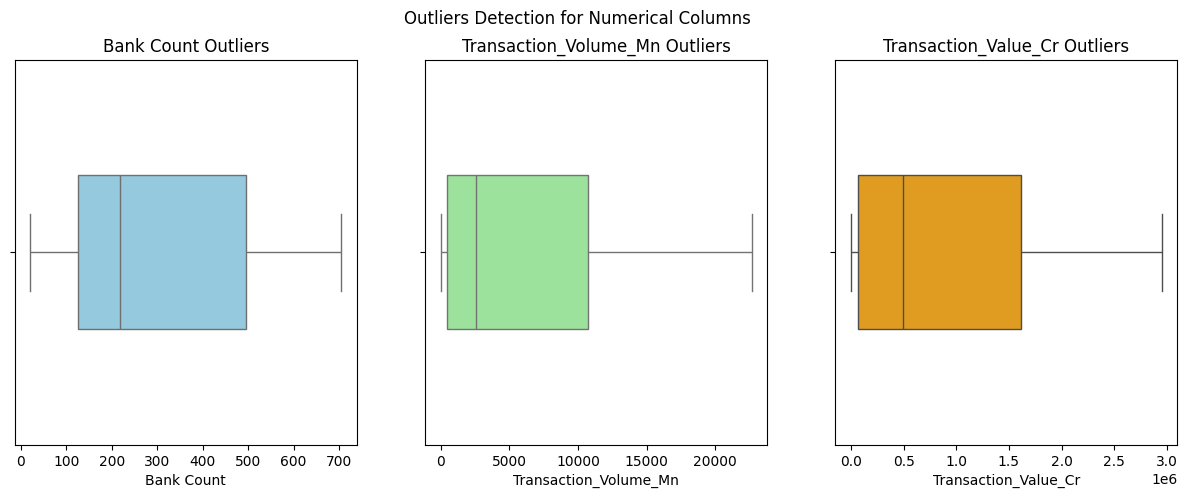

In [35]:
# plotting boxplot for all numeric columns
fig, axes= plt.subplots(1,3, figsize=(15,5))

## checking bank count outliers
sns.boxplot(x='Bank_Count',data=df,width=0.4,color='skyblue',ax=axes[0])
axes[0].set_title('Bank Count Outliers')
axes[0].set_xlabel('Bank Count')

#Checking Transaction_Volume_Mn outliers
sns.boxplot(x='Transaction_Volume_Mn',data=df,width=0.4,color='lightgreen',ax=axes[1])
axes[1].set_title('Transaction_Volume_Mn Outliers')
axes[1].set_xlabel('Transaction_Volume_Mn')

#Checking Transaction_Value_Cr Outliers
sns.boxplot(x='Transaction_Value_Cr',data=df,width=0.4,color='orange',ax=axes[2])
axes[2].set_title('Transaction_Value_Cr Outliers')
axes[2].set_xlabel('Transaction_Value_Cr')

plt.suptitle('Outliers Detection for Numerical Columns')
plt.show()

#### 4.6.3 — Outlier Count using IQR Method

In [36]:
# finding outliers using IQR method
for col in ['Bank_Count', 'Transaction_Volume_Mn', 'Transaction_Value_Cr']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"\n{col}")
    print(f"Q1     : {Q1}")
    print(f"Q3     : {Q3}")
    print(f"IQR    : {IQR}")
    print(f"Lower  : {lower}")
    print(f"Upper  : {upper}")
    print(f"Outliers found: {len(outliers)}")


Bank_Count
Q1     : 126.5
Q3     : 495.25
IQR    : 368.75
Lower  : -426.625
Upper  : 1048.375
Outliers found: 0

Transaction_Volume_Mn
Q1     : 463.2375
Q3     : 10748.337500000001
IQR    : 10285.100000000002
Lower  : -14964.412500000004
Upper  : 26175.987500000003
Outliers found: 0

Transaction_Value_Cr
Q1     : 71192.54250000001
Q3     : 1613291.97
IQR    : 1542099.4275
Lower  : -2241956.59875
Upper  : 3926441.11125
Outliers found: 0


### 4.7 — Handling Outliers

In [37]:
# since we used real government data from NPCI
# data is already verified and accurate
# so no outliers found in any column
print("No outliers found! Data is clean!")

No outliers found! Data is clean!


### 4.8 — Sorting Data

In [38]:
# sorting data by month in ascending order
# so data flows from 2016 to 2026 chronologically
df = df.sort_values('Month', ascending=True)
df = df.reset_index(drop=True)

In [39]:
print("After Sorting:")
print(df.head())
print("Last 5 rows:")
print(df.tail())

After Sorting:
       Month Financial_Year  Bank_Count  Transaction_Volume_Mn  \
0 2016-04-01        2016-17          21                   0.00   
1 2016-05-01        2016-17          21                   0.00   
2 2016-06-01        2016-17          21                   0.00   
3 2016-07-01        2016-17          21                   0.09   
4 2016-08-01        2016-17          21                   0.09   

   Transaction_Value_Cr  
0                  0.00  
1                  0.00  
2                  0.00  
3                  0.38  
4                  3.09  
Last 5 rows:
         Month Financial_Year  Bank_Count  Transaction_Volume_Mn  \
115 2025-11-01        2025-26         684               20466.98   
116 2025-12-01        2025-26         685               21634.67   
117 2026-01-01        2025-26         691               21703.44   
118 2026-02-01        2025-26         694               20394.18   
119 2026-03-01        2025-26         705               22641.11   

     Trans

### 4.10 — Feature Engineering

In [40]:
# extracting year from month column
df['Year'] = df['Month'].dt.year

In [41]:
# extracting month name from month column
df['Month_Name'] = df['Month'].dt.strftime('%B')

In [42]:
df['Month_Number'] = df['Month'].dt.month

In [43]:
# checking new columns
print("After Feautre Engineering:")
df.head()

After Feautre Engineering:


,Month,Financial_Year,Bank_Count,Transaction_Volume_Mn,Transaction_Value_Cr,Year,Month_Name,Month_Number
0,2016-04-01,2016-17,21,0.00,0.00,2016,April,4
1,2016-05-01,2016-17,21,0.00,0.00,2016,May,5
2,2016-06-01,2016-17,21,0.00,0.00,2016,June,6
3,2016-07-01,2016-17,21,0.09,0.38,2016,July,7
4,2016-08-01,2016-17,21,0.09,3.09,2016,August,8


In [44]:
print("New columns Added:")
df.columns.tolist()

New columns Added:


['Month',
 'Financial_Year',
 'Bank_Count',
 'Transaction_Volume_Mn',
 'Transaction_Value_Cr',
 'Year',
 'Month_Name',
 'Month_Number']

### 4.11 — Final Cleaned Data Verification

In [45]:
# final check after all cleaning steps
print("Final Dataset Shape:", df.shape)

Final Dataset Shape: (120, 8)


In [46]:
print("\nFinal Column names\n")
print(df.columns.tolist())


Final Column names

['Month', 'Financial_Year', 'Bank_Count', 'Transaction_Volume_Mn', 'Transaction_Value_Cr', 'Year', 'Month_Name', 'Month_Number']


In [47]:
print("\nFinal Data Types:\n")
print(df.dtypes)


Final Data Types:

Month                    datetime64[ns]
Financial_Year                   object
Bank_Count                        int64
Transaction_Volume_Mn           float64
Transaction_Value_Cr            float64
Year                              int32
Month_Name                       object
Month_Number                      int32
dtype: object


In [48]:
print("\nFinal Missing Values:")
print(df.isnull().sum())


Final Missing Values:
Month                    0
Financial_Year           0
Bank_Count               0
Transaction_Volume_Mn    0
Transaction_Value_Cr     0
Year                     0
Month_Name               0
Month_Number             0
dtype: int64


In [49]:
print("\nFinal Dataset Preview:")
df.head()


Final Dataset Preview:


,Month,Financial_Year,Bank_Count,Transaction_Volume_Mn,Transaction_Value_Cr,Year,Month_Name,Month_Number
0,2016-04-01,2016-17,21,0.00,0.00,2016,April,4
1,2016-05-01,2016-17,21,0.00,0.00,2016,May,5
2,2016-06-01,2016-17,21,0.00,0.00,2016,June,6
3,2016-07-01,2016-17,21,0.09,0.38,2016,July,7
4,2016-08-01,2016-17,21,0.09,3.09,2016,August,8


In [50]:
# saving cleaned data as new csv file
df.to_csv('upi_cleaned_data.csv', index=False)
print("Cleaned data saved successfully!")

Cleaned data saved successfully!


## 
Step 5 — Exploratory Data Analysis (EDA)
### 5.1 — Univariate Analysis
#### 5.1.1 — Year wise UPI Growth Analysis

In [51]:
# grouping data by year to see yearly growth
yearly_data = df.groupby('Year')[['Transaction_Volume_Mn','Transaction_Value_Cr']].sum().reset_index()

In [52]:
print("Yearly wise UPI Growth")
yearly_data

Yearly wise UPI Growth


,Year,Transaction_Volume_Mn,Transaction_Value_Cr
0,2016,2.65,893.07
1,2017,429.15,57020.87
2,2018,3746.32,585710.45
3,2019,10787.54,1836638.18
4,2020,18880.89,3387744.72
5,2021,38744.55,7159285.80
6,2022,74044.48,12595077.87
7,2023,117641.09,18292795.21
8,2024,172208.01,24682520.78
9,2025,228281.85,29974737.57


In [53]:
# removing 2026 data because it is incomplete
# 2025-26 financial year is still ongoing
# incomplete data may give misleading insights in charts
df = df[df['Year'] != 2026]

# confirming 2026 is removed
print("Years in dataset after removing 2026:")
print(df['Year'].unique())

Years in dataset after removing 2026:
[2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]


In [54]:
# regrouping data by year after removing incomplete 2026 data
yearly_data = df.groupby('Year')[['Transaction_Volume_Mn','Transaction_Value_Cr']].sum().reset_index()

print("Year Wise UPI Grwoth")
yearly_data

Year Wise UPI Grwoth


,Year,Transaction_Volume_Mn,Transaction_Value_Cr
0,2016,2.65,893.07
1,2017,429.15,57020.87
2,2018,3746.32,585710.45
3,2019,10787.54,1836638.18
4,2020,18880.89,3387744.72
5,2021,38744.55,7159285.80
6,2022,74044.48,12595077.87
7,2023,117641.09,18292795.21
8,2024,172208.01,24682520.78
9,2025,228281.85,29974737.57


In [55]:
# converting to readable format for better understanding in charts
# volume in billions and value in lakh crores
yearly_data['Volume_Billions'] = (yearly_data['Transaction_Volume_Mn'] / 1000).round(2)
yearly_data['Value_Lakh_Cr'] = (yearly_data['Transaction_Value_Cr'] / 100000).round(2)

print("Year wise UPI Growth:")
yearly_data

Year wise UPI Growth:


,Year,Transaction_Volume_Mn,Transaction_Value_Cr,Volume_Billions,Value_Lakh_Cr
0,2016,2.65,893.07,0.00,0.01
1,2017,429.15,57020.87,0.43,0.57
2,2018,3746.32,585710.45,3.75,5.86
3,2019,10787.54,1836638.18,10.79,18.37
4,2020,18880.89,3387744.72,18.88,33.88
5,2021,38744.55,7159285.80,38.74,71.59
6,2022,74044.48,12595077.87,74.04,125.95
7,2023,117641.09,18292795.21,117.64,182.93
8,2024,172208.01,24682520.78,172.21,246.83
9,2025,228281.85,29974737.57,228.28,299.75


#### 5.1.1 — Year wise UPI Growth Chart

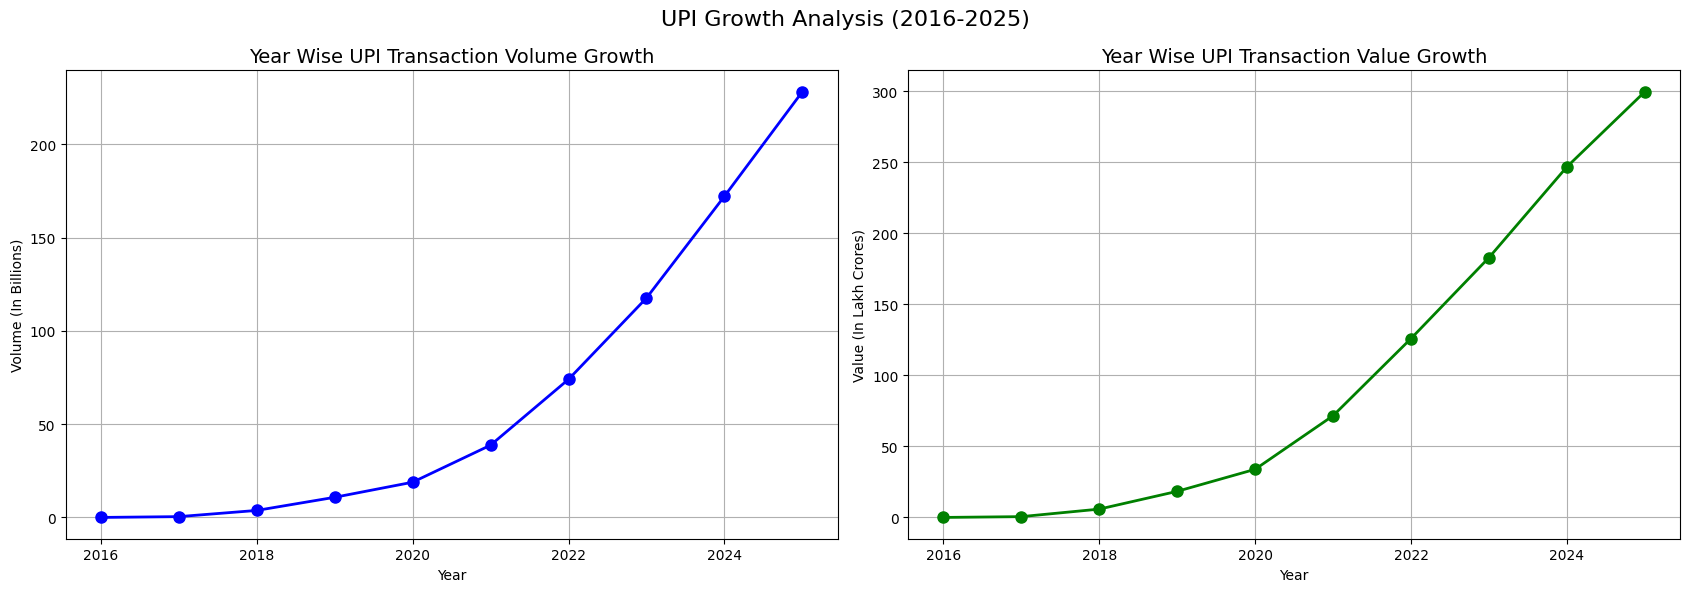

In [56]:
# plotting year wise upi growth
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# transaction volume growth
axes[0].plot(yearly_data['Year'], yearly_data['Volume_Billions'],
             color='blue', marker='o', linewidth=2, markersize=8)
axes[0].set_title('Year Wise UPI Transaction Volume Growth', fontsize=14)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Volume (In Billions)')
axes[0].grid(True)

# transaction value growth
axes[1].plot(yearly_data['Year'], yearly_data['Value_Lakh_Cr'],
             marker='o', color='green', linewidth=2, markersize=8)
axes[1].set_title('Year Wise UPI Transaction Value Growth', fontsize=14)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Value (In Lakh Crores)')
axes[1].grid(True)

# main title
plt.suptitle("UPI Growth Analysis (2016-2025)", fontsize=16)
plt.tight_layout()
plt.show()

In [57]:
# saving the chart to visuals folder
plt.savefig('visuals/year_wise_upi_growth.png', dpi=300, bbox_inches='tight')
print("Chart saved successfully!")

Chart saved successfully!


<Figure size 640x480 with 0 Axes>

In [58]:
import os

# creating visuals folder if not exists
os.makedirs('visuals', exist_ok=True)

# saving the chart to visuals folder
fig.savefig('visuals/year_wise_upi_growth.png', dpi=300, bbox_inches='tight')
print("Chart saved successfully!")

Chart saved successfully!


#### 5.1.2 — Year wise UPI Comparison Bar Chart

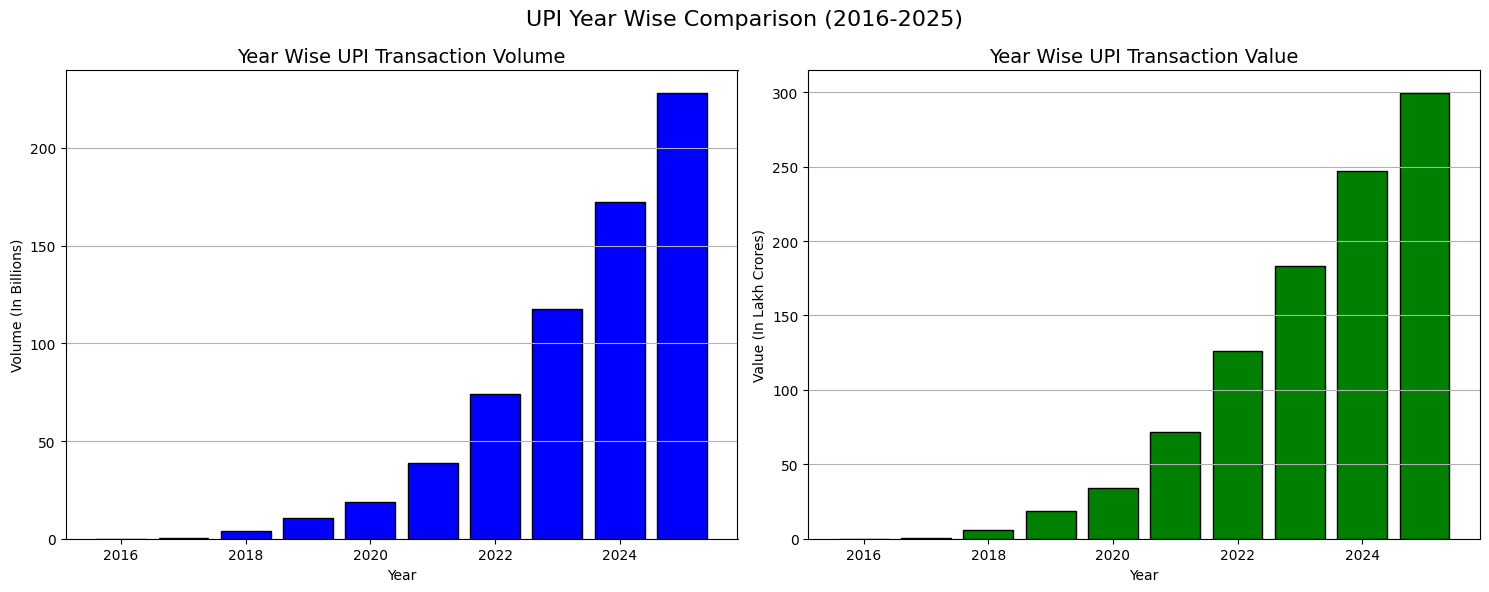

In [59]:
# plotting year wise upi comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# transaction volume bar chart
axes[0].bar(yearly_data['Year'], yearly_data['Volume_Billions'],
            color='blue', edgecolor='black')
axes[0].set_title('Year Wise UPI Transaction Volume', fontsize=14)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Volume (In Billions)')
axes[0].grid(True, axis='y')

# transaction value bar chart
axes[1].bar(yearly_data['Year'], yearly_data['Value_Lakh_Cr'],
            color='green', edgecolor='black')
axes[1].set_title('Year Wise UPI Transaction Value', fontsize=14)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Value (In Lakh Crores)')
axes[1].grid(True, axis='y')

# main title
plt.suptitle("UPI Year Wise Comparison (2016-2025)", fontsize=16)
plt.tight_layout()
plt.show()

In [60]:
# saving chart
os.makedirs('visuals', exist_ok=True)
fig.savefig('visuals/year_wise_bar_chart.png', dpi=300, bbox_inches='tight')
print("Chart saved successfully!")

Chart saved successfully!


### 5.2 — Bivariate Analysis
#### 5.2.1 — Month wise Transaction Trends

In [61]:
df

,Month,Financial_Year,Bank_Count,Transaction_Volume_Mn,Transaction_Value_Cr,Year,Month_Name,Month_Number
0,2016-04-01,2016-17,21,0.00,0.00,2016,April,4
1,2016-05-01,2016-17,21,0.00,0.00,2016,May,5
2,2016-06-01,2016-17,21,0.00,0.00,2016,June,6
3,2016-07-01,2016-17,21,0.09,0.38,2016,July,7
4,2016-08-01,2016-17,21,0.09,3.09,2016,August,8
...,...,...,...,...,...,...,...,...
112,2025-08-01,2025-26,688,20008.31,2485472.91,2025,August,8
113,2025-09-01,2025-26,686,19633.43,2489736.54,2025,September,9
114,2025-10-01,2025-26,683,20700.92,2727790.68,2025,October,10
115,2025-11-01,2025-26,684,20466.98,2631632.63,2025,November,11


In [62]:
monthly_data = df.groupby('Month_Number')[['Transaction_Volume_Mn','Transaction_Value_Cr']].sum().reset_index()

In [63]:
monthly_data

,Month_Number,Transaction_Volume_Mn,Transaction_Value_Cr
0,1,46289.85,7094465.53
1,2,44739.67,6862421.40
2,3,50794.94,7698006.72
3,4,50263.42,7574329.19
4,5,52790.14,7987464.69
5,6,52633.66,7900567.37
6,7,56009.45,8267779.21
7,8,58558.65,8345839.14
8,9,58858.07,8459332.37
9,10,63998.15,9435959.27


In [64]:
# converting to readable format
monthly_data['Volume_Billions'] = (monthly_data['Transaction_Volume_Mn'] / 1000).round(2)
monthly_data['Value_Lakh_Cr'] = (monthly_data['Transaction_Value_Cr'] / 100000).round(2)

In [65]:
monthly_data

,Month_Number,Transaction_Volume_Mn,Transaction_Value_Cr,Volume_Billions,Value_Lakh_Cr
0,1,46289.85,7094465.53,46.29,70.94
1,2,44739.67,6862421.40,44.74,68.62
2,3,50794.94,7698006.72,50.79,76.98
3,4,50263.42,7574329.19,50.26,75.74
4,5,52790.14,7987464.69,52.79,79.87
5,6,52633.66,7900567.37,52.63,79.01
6,7,56009.45,8267779.21,56.01,82.68
7,8,58558.65,8345839.14,58.56,83.46
8,9,58858.07,8459332.37,58.86,84.59
9,10,63998.15,9435959.27,64.00,94.36


In [66]:
#Adding monthly names for better readability 
monthly_names ={1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
monthly_data['Month_Name'] = monthly_data['Month_Number'].map(monthly_names)

In [67]:
print('Monthly Wise UPI Trends')
print(monthly_data[['Month_Name','Volume_Billions','Value_Lakh_Cr']])

Monthly Wise UPI Trends
   Month_Name  Volume_Billions  Value_Lakh_Cr
0         Jan            46.29          70.94
1         Feb            44.74          68.62
2         Mar            50.79          76.98
3         Apr            50.26          75.74
4         May            52.79          79.87
5         Jun            52.63          79.01
6         Jul            56.01          82.68
7         Aug            58.56          83.46
8         Sep            58.86          84.59
9         Oct            64.00          94.36
10        Nov            62.74          91.58
11        Dec            67.09          97.88


In [68]:
monthly_data

,Month_Number,Transaction_Volume_Mn,Transaction_Value_Cr,Volume_Billions,Value_Lakh_Cr,Month_Name
0,1,46289.85,7094465.53,46.29,70.94,Jan
1,2,44739.67,6862421.40,44.74,68.62,Feb
2,3,50794.94,7698006.72,50.79,76.98,Mar
3,4,50263.42,7574329.19,50.26,75.74,Apr
4,5,52790.14,7987464.69,52.79,79.87,May
5,6,52633.66,7900567.37,52.63,79.01,Jun
6,7,56009.45,8267779.21,56.01,82.68,Jul
7,8,58558.65,8345839.14,58.56,83.46,Aug
8,9,58858.07,8459332.37,58.86,84.59,Sep
9,10,63998.15,9435959.27,64.00,94.36,Oct


In [69]:
monthly_data

,Month_Number,Transaction_Volume_Mn,Transaction_Value_Cr,Volume_Billions,Value_Lakh_Cr,Month_Name
0,1,46289.85,7094465.53,46.29,70.94,Jan
1,2,44739.67,6862421.40,44.74,68.62,Feb
2,3,50794.94,7698006.72,50.79,76.98,Mar
3,4,50263.42,7574329.19,50.26,75.74,Apr
4,5,52790.14,7987464.69,52.79,79.87,May
5,6,52633.66,7900567.37,52.63,79.01,Jun
6,7,56009.45,8267779.21,56.01,82.68,Jul
7,8,58558.65,8345839.14,58.56,83.46,Aug
8,9,58858.07,8459332.37,58.86,84.59,Sep
9,10,63998.15,9435959.27,64.00,94.36,Oct


#### 5.2.2 — Month wise Transaction Trends Chart

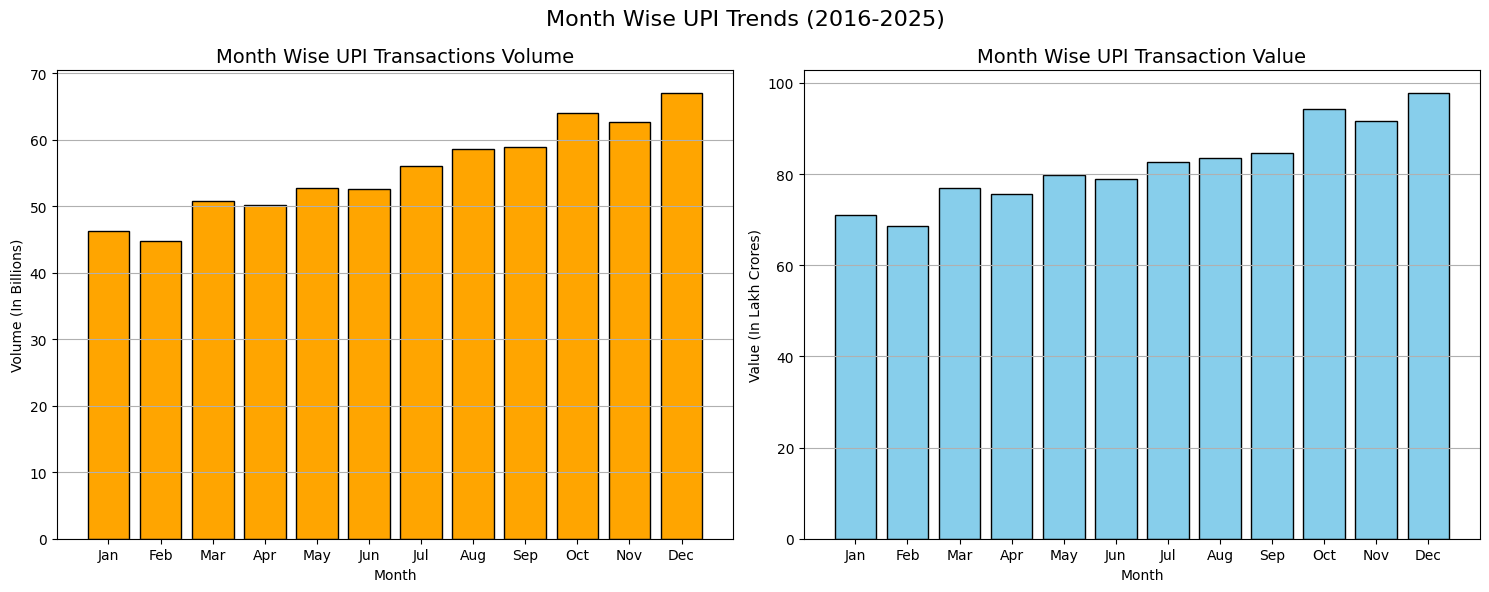

In [70]:
# plotting month wise transaction trends
fig, axes=plt.subplots(1,2, figsize=(15,6))

# month wise volume bar chart
axes[0].bar(monthly_data['Month_Name'],monthly_data['Volume_Billions'],color='orange',edgecolor='black')
axes[0].set_title('Month Wise UPI Transactions Volume',fontsize=14)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Volume (In Billions)')
axes[0].grid(True,axis='y')

#month wise Value bar chart 
axes[1].bar(monthly_data['Month_Name'],monthly_data['Value_Lakh_Cr'],color='skyblue',edgecolor='black')
axes[1].set_title('Month Wise UPI Transaction Value', fontsize=14)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Value (In Lakh Crores)')
axes[1].grid(True, axis='y')

# main title
plt.suptitle('Month Wise UPI Trends (2016-2025)',fontsize=16)
plt.tight_layout()
plt.show()

In [71]:
fig.savefig('visuals/month_wise_trends.png', dpi=300, bbox_inches='tight')
print("Chart saved!")

Chart saved!


### 5.3 — Bank Adoption Analysis

In [72]:
df

,Month,Financial_Year,Bank_Count,Transaction_Volume_Mn,Transaction_Value_Cr,Year,Month_Name,Month_Number
0,2016-04-01,2016-17,21,0.00,0.00,2016,April,4
1,2016-05-01,2016-17,21,0.00,0.00,2016,May,5
2,2016-06-01,2016-17,21,0.00,0.00,2016,June,6
3,2016-07-01,2016-17,21,0.09,0.38,2016,July,7
4,2016-08-01,2016-17,21,0.09,3.09,2016,August,8
...,...,...,...,...,...,...,...,...
112,2025-08-01,2025-26,688,20008.31,2485472.91,2025,August,8
113,2025-09-01,2025-26,686,19633.43,2489736.54,2025,September,9
114,2025-10-01,2025-26,683,20700.92,2727790.68,2025,October,10
115,2025-11-01,2025-26,684,20466.98,2631632.63,2025,November,11


In [73]:
Bank_data = df.groupby('Year')['Bank_Count'].max().reset_index()

In [74]:
print("Year wise Bank Adoption:")
Bank_data

Year wise Bank Adoption:


,Year,Bank_Count
0,2016,35
1,2017,67
2,2018,129
3,2019,144
4,2020,207
5,2021,282
6,2022,382
7,2023,522
8,2024,641
9,2025,688


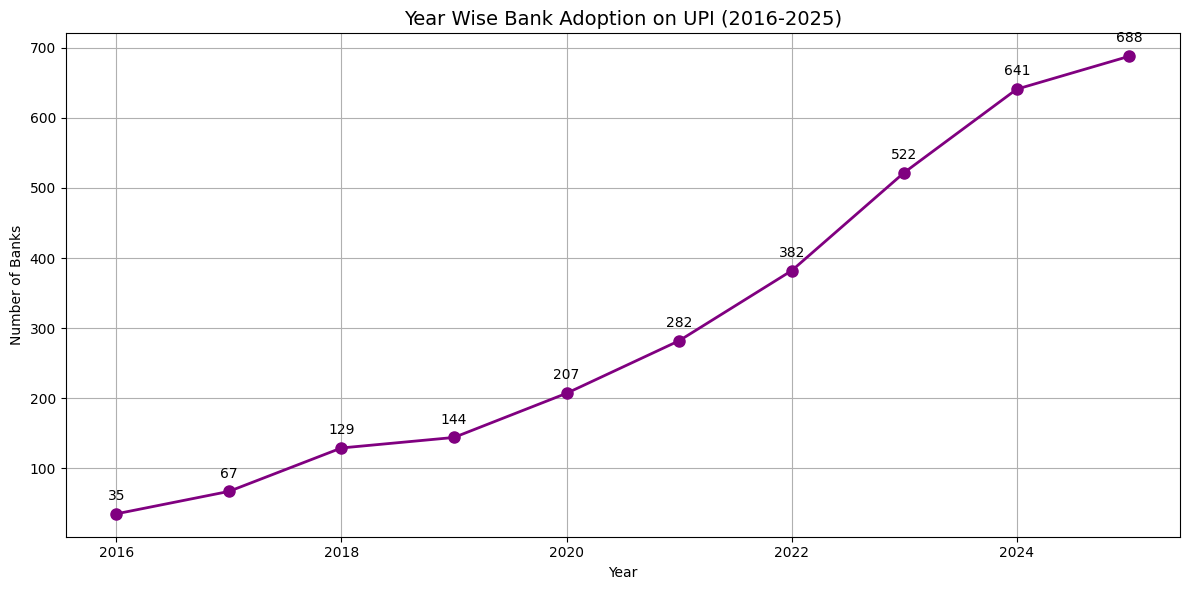

In [75]:
# plotting bank adoption growth over years
fig, ax = plt.subplots(figsize=(12, 6))

# line plot for bank adoption
ax.plot(Bank_data['Year'], Bank_data['Bank_Count'],
        marker='o', color='purple', linewidth=2, markersize=8)

# adding value labels on each point
for x, y in zip(Bank_data['Year'], Bank_data['Bank_Count']):
    ax.annotate(str(y), (x, y), textcoords="offset points",
                xytext=(0, 10), ha='center', fontsize=10)

ax.set_title('Year Wise Bank Adoption on UPI (2016-2025)', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Banks')
ax.grid(True)

plt.tight_layout()
plt.show()

In [76]:
# saving chart
fig.savefig('visuals/bank_adoption.png', dpi=300, bbox_inches='tight')
print("Chart saved!")

Chart saved!


### 5.4 — Post COVID Impact Analysis

In [77]:
# separating pre covid and post covid data
# covid hit india in march 2020
pre_covid = df[df['Year'] < 2020]

In [78]:
print('\nPre-Covid Data:\n')
pre_covid


Pre-Covid Data:



,Month,Financial_Year,Bank_Count,Transaction_Volume_Mn,Transaction_Value_Cr,Year,Month_Name,Month_Number
0,2016-04-01,2016-17,21,0.00,0.00,2016,April,4
1,2016-05-01,2016-17,21,0.00,0.00,2016,May,5
2,2016-06-01,2016-17,21,0.00,0.00,2016,June,6
3,2016-07-01,2016-17,21,0.09,0.38,2016,July,7
4,2016-08-01,2016-17,21,0.09,3.09,2016,August,8
5,2016-09-01,2016-17,25,0.09,32.64,2016,September,9
6,2016-10-01,2016-17,26,0.10,48.57,2016,October,10
7,2016-11-01,2016-17,30,0.29,100.46,2016,November,11
8,2016-12-01,2016-17,35,1.99,707.93,2016,December,12
9,2017-01-01,2016-17,36,4.46,1696.22,2017,January,1


In [79]:
during_covid = df[df['Year'] == 2020 ]

In [80]:
print("\nDuring_Covid_Data:\n")
during_covid


During_Covid_Data:



,Month,Financial_Year,Bank_Count,Transaction_Volume_Mn,Transaction_Value_Cr,Year,Month_Name,Month_Number
45,2020-01-01,2019-20,144,1305.02,216242.97,2020,January,1
46,2020-02-01,2019-20,146,1325.69,222516.95,2020,February,2
47,2020-03-01,2019-20,148,1246.84,206462.31,2020,March,3
48,2020-04-01,2020-21,153,999.57,151140.66,2020,April,4
49,2020-05-01,2020-21,155,1234.50,218391.60,2020,May,5
50,2020-06-01,2020-21,155,1336.93,261835.00,2020,June,6
51,2020-07-01,2020-21,164,1497.36,290537.86,2020,July,7
52,2020-08-01,2020-21,168,1618.83,298307.61,2020,August,8
53,2020-09-01,2020-21,174,1800.14,329027.66,2020,September,9
54,2020-10-01,2020-21,189,2071.62,386106.74,2020,October,10


In [81]:
post_covid = df[df['Year'] > 2020]

In [82]:
print('\nPost_Covid_Data:\n')
post_covid


Post_Covid_Data:



,Month,Financial_Year,Bank_Count,Transaction_Volume_Mn,Transaction_Value_Cr,Year,Month_Name,Month_Number
57,2021-01-01,2020-21,207,2302.73,431181.89,2021,January,1
58,2021-02-01,2020-21,213,2292.90,425062.76,2021,February,2
59,2021-03-01,2020-21,216,2731.68,504886.44,2021,March,3
60,2021-04-01,2021-22,220,2641.06,493663.68,2021,April,4
61,2021-05-01,2021-22,224,2539.57,490638.65,2021,May,5
62,2021-06-01,2021-22,229,2807.51,547373.17,2021,June,6
63,2021-07-01,2021-22,235,3247.82,606281.14,2021,July,7
64,2021-08-01,2021-22,249,3555.55,639116.95,2021,August,8
65,2021-09-01,2021-22,259,3654.30,654351.81,2021,September,9
66,2021-10-01,2021-22,261,4218.65,771444.98,2021,October,10


In [83]:
# grouping each period by year
pre_covid_data = pre_covid.groupby('Year')[['Transaction_Volume_Mn','Transaction_Value_Cr']].sum().reset_index()

In [84]:
during_covid_data = during_covid.groupby('Year')[['Transaction_Volume_Mn','Transaction_Value_Cr']].sum().reset_index()

In [85]:
post_covid_data = post_covid.groupby('Year')[['Transaction_Volume_Mn','Transaction_Value_Cr']].sum().reset_index()

In [86]:
for  data in [pre_covid_data,during_covid_data,post_covid_data]:
    data['Volume_Billions'] = (data['Transaction_Volume_Mn']/1000).round(2)
    data['Value_Lakh_Cr'] = (data['Transaction_Value_Cr']/100000).round(2)

In [87]:
print('\nPre_COVID_Data\n')
pre_covid_data


Pre_COVID_Data



,Year,Transaction_Volume_Mn,Transaction_Value_Cr,Volume_Billions,Value_Lakh_Cr
0,2016,2.65,893.07,0.00,0.01
1,2017,429.15,57020.87,0.43,0.57
2,2018,3746.32,585710.45,3.75,5.86
3,2019,10787.54,1836638.18,10.79,18.37


In [88]:
print('\nDuring_COVID_Data\n')
during_covid_data


During_COVID_Data



,Year,Transaction_Volume_Mn,Transaction_Value_Cr,Volume_Billions,Value_Lakh_Cr
0,2020,18880.89,3387744.72,18.88,33.88


In [89]:
print('\nPost_COVID_Data\n')
post_covid_data


Post_COVID_Data



,Year,Transaction_Volume_Mn,Transaction_Value_Cr,Volume_Billions,Value_Lakh_Cr
0,2021,38744.55,7159285.80,38.74,71.59
1,2022,74044.48,12595077.87,74.04,125.95
2,2023,117641.09,18292795.21,117.64,182.93
3,2024,172208.01,24682520.78,172.21,246.83
4,2025,228281.85,29974737.57,228.28,299.75


In [90]:
yearly_data

,Year,Transaction_Volume_Mn,Transaction_Value_Cr,Volume_Billions,Value_Lakh_Cr
0,2016,2.65,893.07,0.00,0.01
1,2017,429.15,57020.87,0.43,0.57
2,2018,3746.32,585710.45,3.75,5.86
3,2019,10787.54,1836638.18,10.79,18.37
4,2020,18880.89,3387744.72,18.88,33.88
5,2021,38744.55,7159285.80,38.74,71.59
6,2022,74044.48,12595077.87,74.04,125.95
7,2023,117641.09,18292795.21,117.64,182.93
8,2024,172208.01,24682520.78,172.21,246.83
9,2025,228281.85,29974737.57,228.28,299.75



**Analysis Approach:**
I used line chart to show the complete UPI growth journey 
and bar chart to compare Pre COVID, During COVID and Post COVID periods.
Both charts together tell the complete COVID impact story on India's digital payments!

#### 5.4.1 — COVID Impact Line Chart

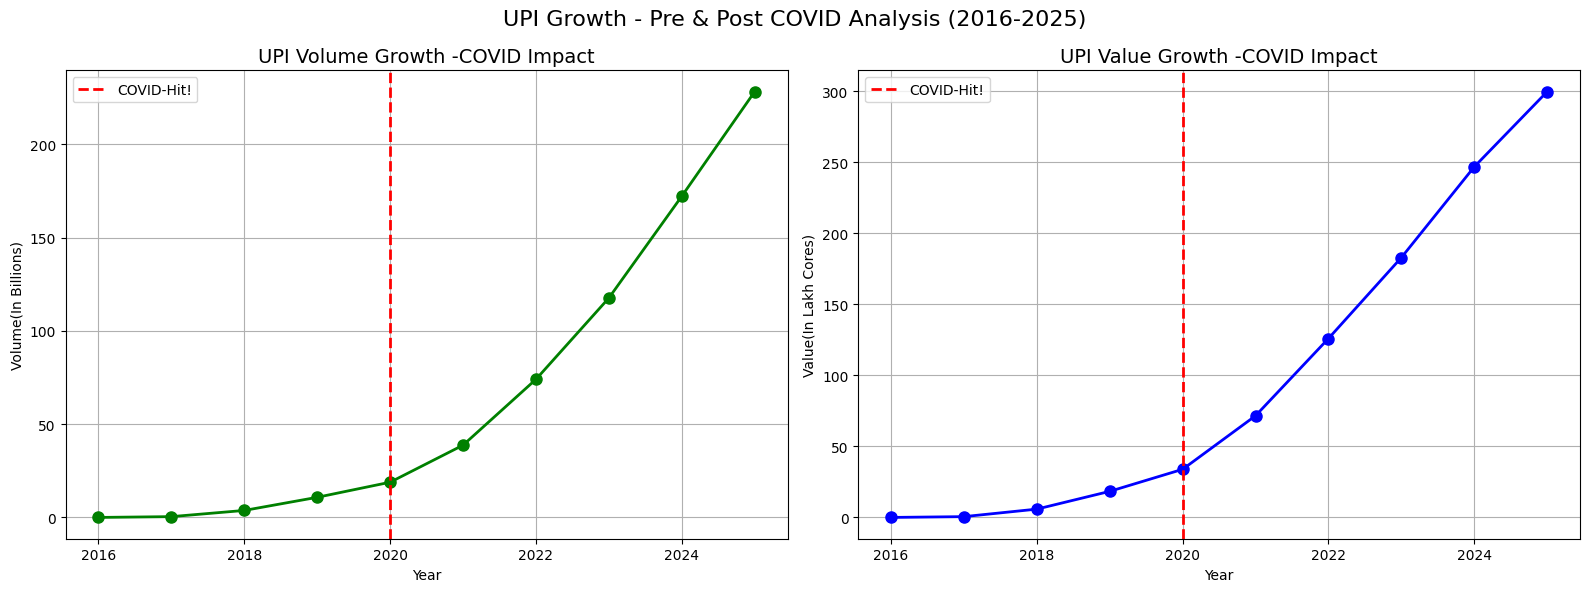

In [91]:
# plotting covid impact using line chart with marker
fig, axes = plt.subplots(1,2, figsize=(16,6))

# volume line chart with covid marker
axes[0].plot(yearly_data['Year'],yearly_data['Volume_Billions'],marker='o',markersize=8,linewidth=2,color='green')
axes[0].axvline(x=2020,linestyle='--',linewidth=2,color='red',label='COVID-Hit!')
axes[0].set_title('UPI Volume Growth -COVID Impact',fontsize=14)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Volume(In Billions)')
axes[0].legend()
axes[0].grid(True)

# Value line chart with covid maker
axes[1].plot(yearly_data['Year'],yearly_data['Value_Lakh_Cr'],marker='o',markersize=8,linewidth=2,color='blue')
axes[1].axvline(x=2020,linestyle='--',linewidth=2,color='red',label='COVID-Hit!')
axes[1].set_title('UPI Value Growth -COVID Impact',fontsize=14)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Value(In Lakh Cores)')
axes[1].legend()
axes[1].grid(True)
                         
plt.suptitle('UPI Growth - Pre & Post COVID Analysis (2016-2025)',fontsize=16)
plt.tight_layout()
plt.show()             

In [92]:
# saving chart
fig.savefig('visuals/covid_impact_line.png', dpi=300, bbox_inches='tight')
print("Chart saved!")

Chart saved!


In [93]:
# combining all periods for grouped bar chart
covid_comparison =pd.DataFrame({'Period':['Pre COVID\n(2016-2019)','During COVID\n(2020)','Post COVID\n(2021-2025)'],
                                'Volume_Billions':[pre_covid_data['Volume_Billions'].sum(),
                                                   during_covid_data['Volume_Billions'].sum(),
                                                   post_covid_data['Volume_Billions'].sum()],
                                'Value_Lakh_Cr':[pre_covid_data['Value_Lakh_Cr'].sum(),
                                                during_covid_data['Value_Lakh_Cr'].sum(),
                                                post_covid_data['Value_Lakh_Cr'].sum()]
})
print("COVID Period Comparison:")
covid_comparison

COVID Period Comparison:


,Period,Volume_Billions,Value_Lakh_Cr
0,Pre COVID\n(2016-2019),14.97,24.81
1,During COVID\n(2020),18.88,33.88
2,Post COVID\n(2021-2025),630.91,927.05


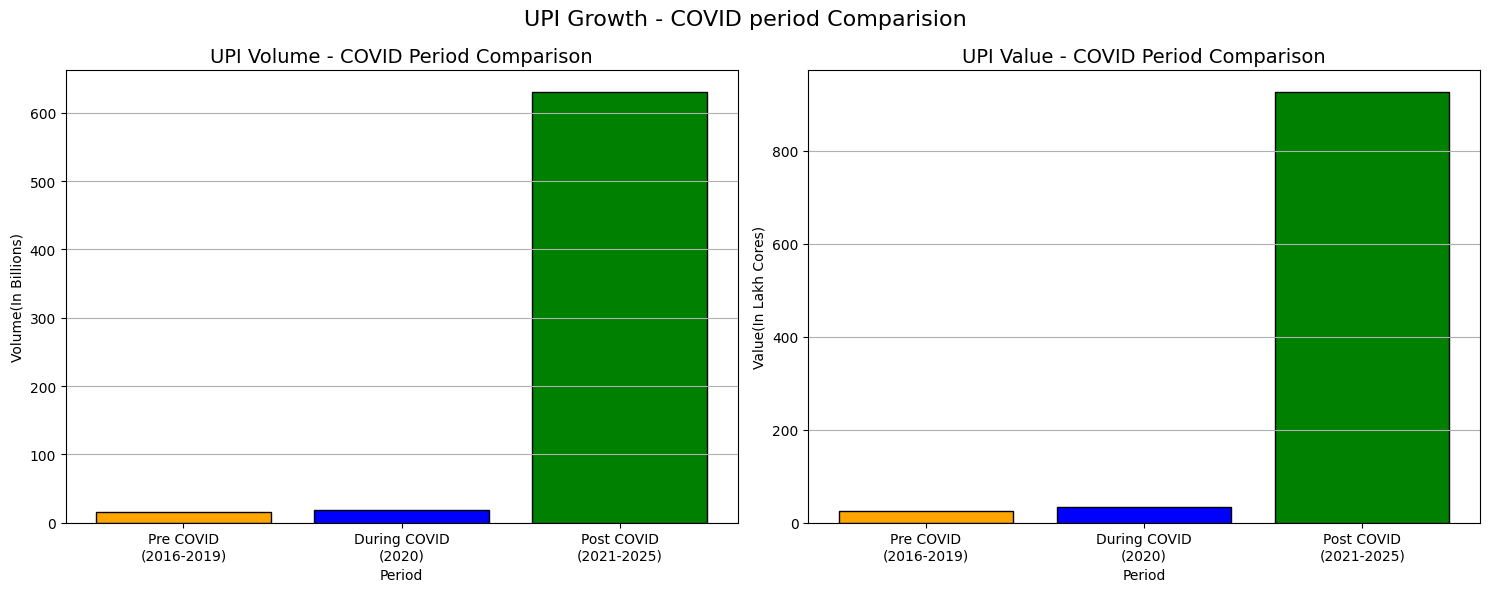

In [94]:
fig, axes=plt.subplots(1,2, figsize=(15,6))

#Volume Grouped Bar
axes[0].bar(covid_comparison['Period'],covid_comparison['Volume_Billions'],
           color=['orange','blue','green'],edgecolor='black')
axes[0].set_title('UPI Volume - COVID Period Comparison',fontsize=14)
axes[0].set_xlabel('Period')
axes[0].set_ylabel('Volume(In Billions)')
axes[0].grid(True, axis='y')

#Value Grouped Bar
axes[1].bar(covid_comparison['Period'],covid_comparison['Value_Lakh_Cr'],
           color=['orange','blue','green'],edgecolor='black')
axes[1].set_title('UPI Value - COVID Period Comparison',fontsize=14)
axes[1].set_xlabel('Period')
axes[1].set_ylabel('Value(In Lakh Cores)')
axes[1].grid(True,axis='y')

plt.suptitle("UPI Growth - COVID period Comparision",fontsize=16)
plt.tight_layout()
plt.show()

In [95]:
# saving chart
fig.savefig('visuals/covid_impact_bar.png', dpi=300, bbox_inches='tight')
print("Chart saved!")

Chart saved!


### 5.5 — Multivariate Analysis
#### 5.5.1 — Correlation Analysis

**Analysis Approach:**
 * Correlation analysis helps me understand how different columns are related to each other.
      - If correlation is close to 1 - strong positive relationship.
      - If correlation is close to 0 - no relationship.
      - If correlation is close to -1 - strong negative relationship.

In [96]:
df.sample()

,Month,Financial_Year,Bank_Count,Transaction_Volume_Mn,Transaction_Value_Cr,Year,Month_Name,Month_Number
103,2024-11-01,2024-25,637,15482.02,2155187.4,2024,November,11


In [97]:
correlation = df[['Bank_Count','Transaction_Volume_Mn','Transaction_Value_Cr']].corr()

In [98]:
print('\nCorrelation Matrix:\n')
correlation


Correlation Matrix:



,Bank_Count,Transaction_Volume_Mn,Transaction_Value_Cr
Bank_Count,1.000000,0.981856,0.992395
Transaction_Volume_Mn,0.981856,1.000000,0.993700
Transaction_Value_Cr,0.992395,0.993700,1.000000


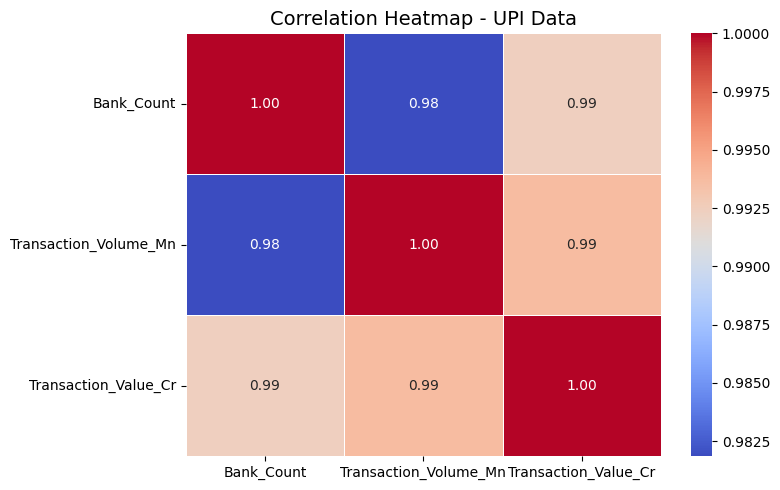

In [99]:
# plotting correlation heatmap using seaborn
fig, ax= plt.subplots(figsize=(8,5))

sns.heatmap(correlation,annot=True,cmap='coolwarm',fmt='.2f',linewidth=0.4,ax=ax)

ax.set_title('Correlation Heatmap - UPI Data', fontsize=14)
plt.tight_layout()
plt.show()


In [100]:
# saving chart
fig.savefig('visuals/correlation_heatmap.png', dpi=300, bbox_inches='tight')
print("Chart saved!")

Chart saved!


In [101]:
         df

,Month,Financial_Year,Bank_Count,Transaction_Volume_Mn,Transaction_Value_Cr,Year,Month_Name,Month_Number
0,2016-04-01,2016-17,21,0.00,0.00,2016,April,4
1,2016-05-01,2016-17,21,0.00,0.00,2016,May,5
2,2016-06-01,2016-17,21,0.00,0.00,2016,June,6
3,2016-07-01,2016-17,21,0.09,0.38,2016,July,7
4,2016-08-01,2016-17,21,0.09,3.09,2016,August,8
...,...,...,...,...,...,...,...,...
112,2025-08-01,2025-26,688,20008.31,2485472.91,2025,August,8
113,2025-09-01,2025-26,686,19633.43,2489736.54,2025,September,9
114,2025-10-01,2025-26,683,20700.92,2727790.68,2025,October,10
115,2025-11-01,2025-26,684,20466.98,2631632.63,2025,November,11


In [102]:
# saving in current folder first
df.to_csv('upi_cleaned_data_new.csv', index=False, encoding='utf-8')
print("CSV saved!")

CSV saved!


In [103]:
# Final Project Summary
print("="*50)
print("UPI PAYMENT TRENDS ANALYSIS - COMPLETE!")
print("="*50)
print(f"Total Records Analyzed: {len(df)}")
print(f"Date Range: {df['Year'].min()} - {df['Year'].max()}")
print(f"Total Transaction Volume: {df['Transaction_Volume_Mn'].sum():.2f} Million")
print(f"Total Transaction Value: {df['Transaction_Value_Cr'].sum():.2f} Crore")
print(f"Banks Onboarded: {df['Bank_Count'].max()}")
print("="*50)

UPI PAYMENT TRENDS ANALYSIS - COMPLETE!
Total Records Analyzed: 117
Date Range: 2016 - 2025
Total Transaction Volume: 664766.53 Million
Total Transaction Value: 98572424.52 Crore
Banks Onboarded: 688


## Conclusion

After analysing 10 years of UPI data, I found some interesting patterns:

- Transaction volume grew from almost 0 to over 228 billion transactions between 2016 and 2025
- Bank participation also increased massively, from just 21 banks to 688 banks on UPI
- The post-COVID period (2021-2025) alone contributed around 95% of the total transaction volume, which clearly shows how COVID pushed people towards digital payments

This project helped me practice the full data analysis workflow:

- Collecting data from Excel files
- Cleaning it in Python
- Writing SQL queries for deeper analysis
- Building a dashboard in Power BI